In [11]:
import sys
sys.path.append("../src")
from data import get_datasets
from tensorflow import keras
import matplotlib.pyplot as plt

train_ds, val_ds, test_ds, class_names = get_datasets(img_size=(128, 128))
print(len(class_names), "classes")

15 classes


In [12]:
train_ds = train_ds.ignore_errors()
val_ds = val_ds.ignore_errors()

In [13]:
model = keras.Sequential([
    keras.layers.Input(shape=(128, 128, 3)),
    keras.layers.RandomFlip("horizontal_and_vertical"),
    keras.layers.RandomRotation(0.1),
    keras.layers.Rescaling(1./255),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(128, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(len(class_names), activation="softmax"),
])
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import os
from PIL import Image

data_dir = r"PUT YOUR FOLDER PATH HERE"
bad = []

for root, _, files in os.walk(data_dir):
    for f in files:
        p = os.path.join(root, f)
        try:
            if os.path.getsize(p) == 0:
                raise ValueError("empty file")
            with Image.open(p) as img:
                img.verify()
        except Exception:
            bad.append(p)

print(f"Found {len(bad)} bad files")
for p in bad:
    print(p)
    os.remove(p)

Found 0 bad files


In [15]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


c:\Users\advai\Documents\plant-disease-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


    515/Unknown 72s 136ms/step - accuracy: 0.5971 - loss: 1.2409

c:\Users\advai\Documents\plant-disease-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 75s 142ms/step - accuracy: 0.5971 - loss: 1.2409 - val_accuracy: 0.7389 - val_loss: 0.7466
Epoch 2/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 69s 134ms/step - accuracy: 0.7917 - loss: 0.6185 - val_accuracy: 0.7970 - val_loss: 0.5975
Epoch 3/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 71s 138ms/step - accuracy: 0.8356 - loss: 0.4823 - val_accuracy: 0.8740 - val_loss: 0.3796
Epoch 4/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 71s 138ms/step - accuracy: 0.8704 - loss: 0.3832 - val_accuracy: 0.8464 - val_loss: 0.4566
Epoch 5/5
515/515 ━━━━━━━━━━━━━━━━━━━━ 72s 139ms/step - accuracy: 0.8811 - loss: 0.3370 - val_accuracy: 0.8072 - val_loss: 0.6148


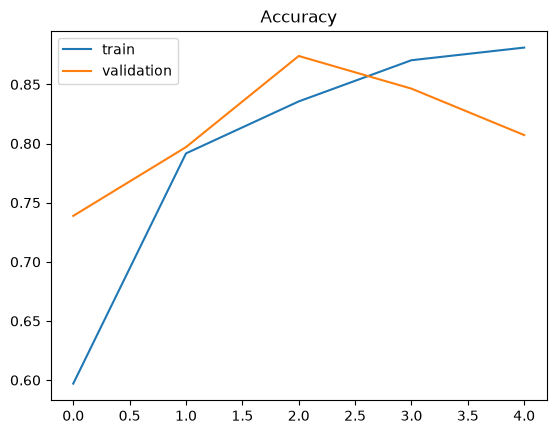

In [16]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.legend()
plt.title("Accuracy")
plt.show()